In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dharsininakulan/wine-dataset/wine_dataset.csv


In [7]:
df=pd.read_csv('/kaggle/input/datasets/dharsininakulan/wine-dataset/wine_dataset.csv')
df.head()


target
1    71
0    59
2    48
Name: count, dtype: int64

In [23]:
df=df.fillna(df.mean(numeric_only=True))
X=df.iloc[:,:3]
y=df.iloc[:,-1]

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [30]:
class LinearRegression:
    
    def __init__(self,lr=0.01):
        self.lr=lr
        self.w=None
        self.b=None
        #stores learning rate, weights(w), and biases(b)
        
    def initialize_parameters(self,n_features):
        self.w = np.zeros((n_features, 1))
        self.b = 0
        

    def forward(self,X):
        return np.dot(X,self.w) + self.b
        #y=mx+b, where m=w(weights), b=biases

    def compute_cost(self,y,y_pred):
        m=y.shape[0]
        cost=(1/(2*m)) * np.sum((y_pred-y)**2)
        return cost

    def backward(self,X,y,y_pred):
        m=X.shape[0]
        dw=(1/m) * np.dot(X.T,(y_pred-y))
        db=(1/m) * np.sum(y_pred-y)
        return dw,db

    def fit(self, X, y, iterations, plot_cost=True):
        y=np.array(y).reshape(-1,1)
        self.initialize_parameters(X.shape[1])

        for i in range(iterations):
            y_pred=self.forward(X)
            cost=self.compute_cost(y,y_pred)

            if np.isnan(cost):
                print(f"NaN detected at iteration {i}")
                print(f"Weights: {self.w}")
                print(f"Bias: {self.b}")
                break

        
            dw,db=self.backward(X,y,y_pred)
            
            self.w-=self.lr*dw
            self.b-=self.lr*db

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")
            
    def predict(self, X):
        return self.forward(X)
    
    def save_model(self, filename=None):
        import pickle
        with open(filename,'wb') as f:
            pickle.dump(self,f)
    
    @classmethod
    def load_model(cls, filename):
        import pickle
        with open('filename',rb) as f:
            return pickle.load(f)

   

In [31]:
lr = LinearRegression(lr=0.001)

lr.fit(X_train, y_train,iterations=10000)

lr.save_model('model.pkl')

In [33]:
class RegressionMetrics:
    @staticmethod
    def mean_squared_error(y, y_pred):
        y = np.array(y).reshape(-1, 1)       
        y_pred = np.array(y_pred).reshape(-1, 1)
        return np.mean((y-y_pred)**2)
        
    @staticmethod
    def root_mean_squared_error(y, y_pred):
        y = np.array(y).reshape(-1, 1)        
        y_pred = np.array(y_pred).reshape(-1, 1)
        mse=np.mean((y-y_pred)**2)
        return np.sqrt(mse)
        
    @staticmethod
    def r_squared(y, y_pred):
        y=np.array(y).reshape(-1,1)
        y_pred=np.array(y_pred).reshape(-1,1)
        ssr=np.sum((y-y_pred)**2)
        sst=np.sum((y-np.mean(y))**2)
        return 1-(ssr/sst)

In [34]:
y_pred = lr.predict(X_test)
mse_value = RegressionMetrics.mean_squared_error(y_test, y_pred)
rmse_value = RegressionMetrics.root_mean_squared_error(y_test, y_pred)
r_squared_value = RegressionMetrics.r_squared(y_test, y_pred)


print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"R-squared (Coefficient of Determination): {r_squared_value}")

Mean Squared Error (MSE): 0.3883487024473126
Root Mean Squared Error (RMSE): 0.6231763012561635
R-squared (Coefficient of Determination): 0.3342593672331782


We can find if a column is related to another, and if yes, how, using the correlation matrix, and plotting a heatmap

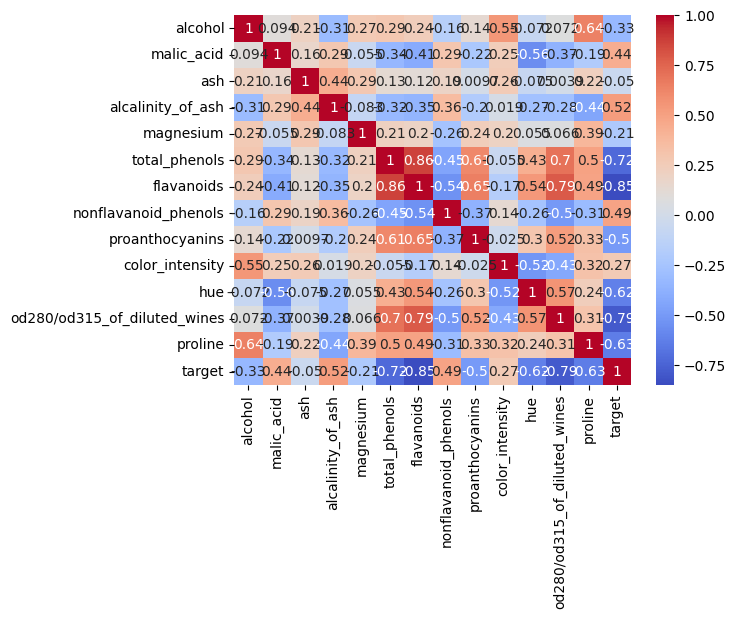

In [35]:
df.corr()

# heatmap for visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()